<a href="https://colab.research.google.com/github/Sargunnn/Human-Activity-Recognition-using-Smartphone-Sensor-Data/blob/main/HAR_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/human+activity+recognition+using+smartphones.zip'
extract_path = '/content/UCI_HAR_Dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


In [ ]:
import os

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


UCI_HAR_Dataset/
  UCI HAR Dataset.names
  UCI HAR Dataset.zip


In [ ]:
import zipfile

inner_zip_path = '/content/UCI_HAR_Dataset/UCI HAR Dataset.zip'
second_extract_path = '/content/UCI_HAR_Dataset/inner'

with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
    zip_ref.extractall(second_extract_path)

print("Inner zip extracted.")


Inner zip extracted.


In [ ]:
import os

for root, dirs, files in os.walk(second_extract_path):
    level = root.replace(second_extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


inner/
  __MACOSX/
    ._UCI HAR Dataset
    UCI HAR Dataset/
      ._train
      ._.DS_Store
      ._activity_labels.txt
      ._features_info.txt
      ._test
      ._README.txt
      ._features.txt
      test/
        ._y_test.txt
        ._subject_test.txt
        ._Inertial Signals
        ._X_test.txt
        Inertial Signals/
          ._body_acc_y_test.txt
          ._total_acc_y_test.txt
          ._body_gyro_z_test.txt
          ._body_acc_x_test.txt
          ._body_gyro_x_test.txt
          ._body_acc_z_test.txt
          ._total_acc_z_test.txt
          ._total_acc_x_test.txt
          ._body_gyro_y_test.txt
      train/
        ._subject_train.txt
        ._y_train.txt
        ._X_train.txt
        ._Inertial Signals
        Inertial Signals/
          ._total_acc_y_train.txt
          ._body_acc_x_train.txt
          ._body_gyro_y_train.txt
          ._body_gyro_z_train.txt
          ._body_acc_y_train.txt
          ._total_acc_x_train.txt
          ._total_acc_z_train.t

In [ ]:
import pandas as pd

# Load features (column names)
features = pd.read_csv("/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/features.txt", sep="\s+", header=None, usecols=[1])
feature_names = features[1].tolist()

# Load training set
X_train = pd.read_csv('/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/train/X_train.txt',
                      sep='\s+', header=None)
y_train = pd.read_csv('/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/train/y_train.txt',
                      sep='\s+', header=None)
subject_train=pd.read_csv('/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/train/subject_train.txt',
                      sep='\s+', header=None)
# Load test set
X_test = pd.read_csv('/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/test/X_test.txt',
                     sep='\s+', header=None)
y_test = pd.read_csv('/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/test/y_test.txt',
                     sep='\s+', header=None)
subject_test=pd.read_csv('/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/test/subject_test.txt',
                      sep='\s+', header=None)

print("Dataset is Loaded!!")

Dataset is Loaded!!


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import keras
from keras.models import load_model
from sklearn.preprocessing import StandardScaler
import keras
from keras import layers
from keras.models import Model
import tensorflow as tf
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

In [ ]:
def plot_model_np(history, title):
    x = np.arange(len(history["val_accuracy"]))
    plt.plot(x, history["loss"], label="loss")
    plt.plot(x, history["val_loss"], label="val_loss")
    plt.plot(x, history["accuracy"], label="accuracy")
    plt.plot(x, history["val_accuracy"], label="val_accuracy")
    plt.title(title)
    plt.legend()

def confusion_matrix_plot(Model):
    Model_predict = Model.predict( X_test_lda ) # Use LDA transformed test features
    Model_predict = np.argmax(Model_predict, axis=1)
    cm = confusion_matrix(Model_predict, test_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=activity_labels_df['activity_name'], yticklabels=activity_labels_df['activity_name'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [ ]:
import pandas as pd

# Concatenate features
all_features = pd.concat([X_train, X_test], ignore_index=True)

# Concatenate labels
all_labels = pd.concat([y_train, y_test], ignore_index=True)

# Concatenate subjects
all_subjects = pd.concat([subject_train, subject_test], ignore_index=True)

# Assign feature names to all_features
all_features.columns = feature_names

# Read activity labels
activity_labels_df = pd.read_csv("/content/UCI_HAR_Dataset/inner/UCI HAR Dataset/activity_labels.txt", sep="\s+", header=None, names=['label_id', 'activity_name'])

# Merge labels with activity names
activity_labels = pd.merge(all_labels, activity_labels_df, left_on=0, right_on='label_id', how='left')

# Combine all dataframes
combined_df = pd.concat([all_subjects, all_features, activity_labels[['activity_name']]], axis=1)

# Rename subject column
combined_df.rename(columns={0: 'subject_id'}, inplace=True)

# Print the first few rows and shape
display(combined_df.head())
print("Shape of the combined DataFrame:", combined_df.shape)

,subject_id,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity_name
0,1,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,1,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,1,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,1,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


Shape of the combined DataFrame: (10299, 563)


In [ ]:
# Define the number of rows in the original training and test sets
train_size = len(X_train)
test_size = len(X_test)

# Split the combined dataframe back into train and test dataframes
train_df = combined_df.iloc[:train_size]
test_df = combined_df.iloc[train_size:]

train_features = train_df.drop(["activity_name", "subject_id"], axis=1)
test_features = test_df.drop(["activity_name", "subject_id"], axis=1)

train_labels = train_df["activity_name"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])
test_labels = test_df["activity_name"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])

/tmp/ipython-input-17-3038267538.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_labels = train_df["activity_name"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])
/tmp/ipython-input-17-3038267538.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_labels = test_df["activity_name"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])


In [ ]:
print('Shape of Train data : ', train_df.shape)
print('Shape of X_Train : ', train_features.shape)
print('Shape of Train class : ', train_labels.shape)
print('Shape of Test data : ', test_df.shape)
print('Shape of X_test : ', test_features.shape)
print('Shape of Test class : ', test_labels.shape)

Shape of Train data :  (7352, 563)
Shape of X_Train :  (7352, 561)
Shape of Train class :  (7352,)
Shape of Test data :  (2947, 563)
Shape of X_test :  (2947, 561)
Shape of Test class :  (2947,)


In [ ]:
train_features

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


In [ ]:
from sklearn import discriminant_analysis

lda = discriminant_analysis.LinearDiscriminantAnalysis(n_components=5)
lda.fit(train_features, train_labels)  # fit with training data

X_train_lda = lda.transform(train_features)   # transform training features
X_test_lda = lda.transform(test_features)     # transform test features

# transform() method of LDA only takes features not the labels

In [ ]:
def build_nn_model(input_shape, num_classes):
  model = keras.Sequential([
      layers.Input(shape=input_shape),
      layers.Dense(128, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(32, activation='relu'),
      layers.Dense(num_classes, activation='softmax')
  ])
  return model

# Get input shape (number of features after LDA)
input_shape = (X_train_lda.shape[1],)
# Get number of output classes
num_classes = len(activity_labels_df) # Or you can use len(np.unique(y_train))

# Build the model
nn_model = build_nn_model(input_shape, num_classes)

# Compile the model
nn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Print model summary
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,302 (44.15 KB)

 Trainable params: 11,302 (44.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7704 - loss: 0.7852 - val_accuracy: 0.9937 - val_loss: 0.0288
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9838 - loss: 0.0454 - val_accuracy: 0.9923 - val_loss: 0.0229
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.0535 - val_accuracy: 0.9946 - val_loss: 0.0215
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9807 - loss: 0.0446 - val_accuracy: 0.9927 - val_loss: 0.0222
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9833 - loss: 0.0399 - val_accuracy: 0.9882 - val_loss: 0.0288


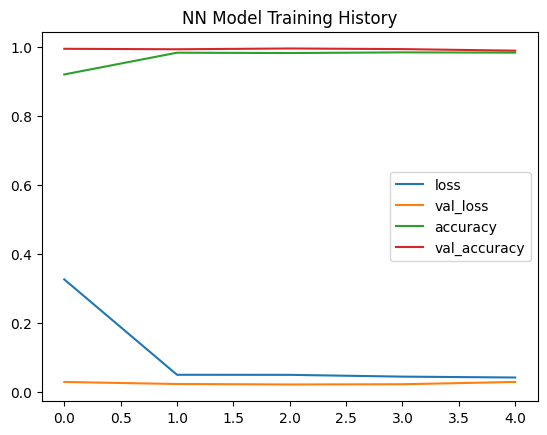

In [ ]:
graph=nn_model.fit(X_train_lda,train_labels,epochs=5,batch_size=60,validation_split=0.3)
plot_model_np(graph.history,"NN Model Training History")

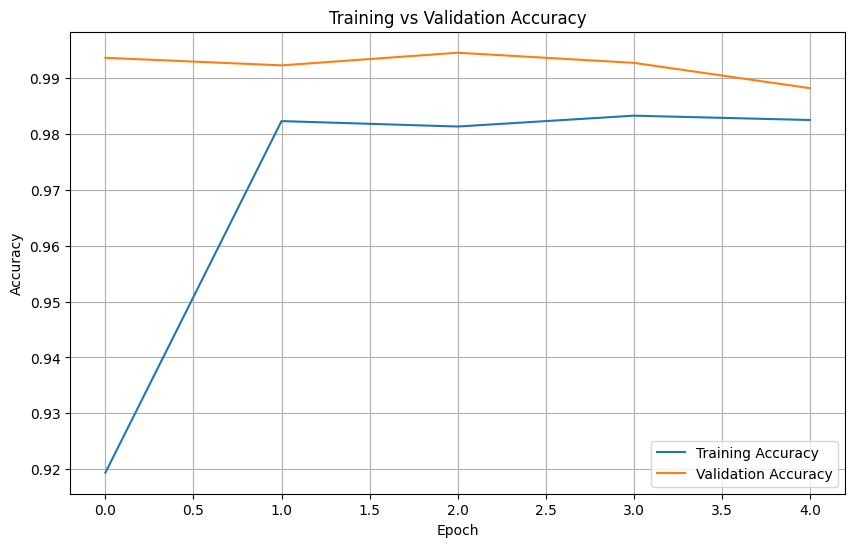

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(graph.history['accuracy'], label='Training Accuracy')
plt.plot(graph.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


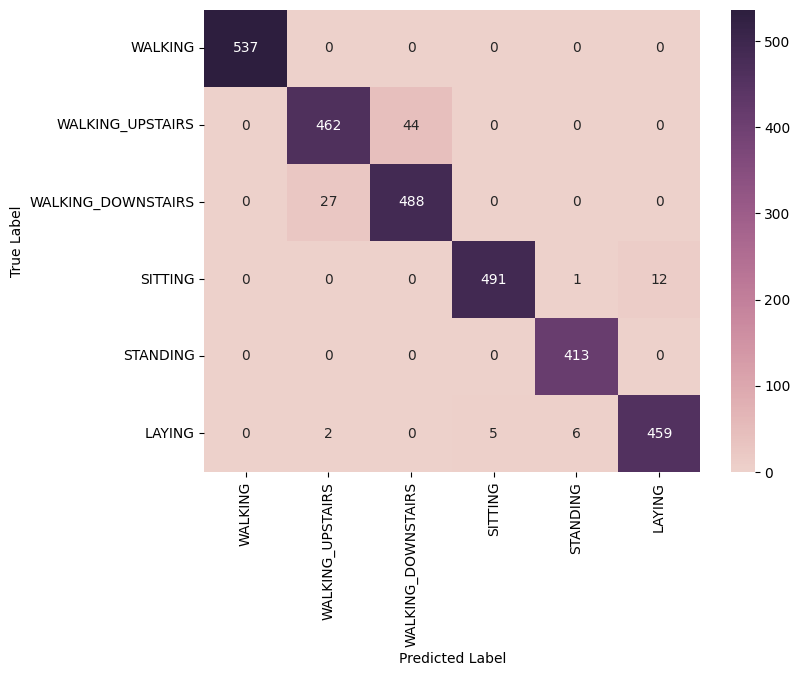

In [ ]:
confusion_matrix_plot(nn_model)

In [ ]:
# Make predictions on the test data
y_pred = nn_model.predict(X_test_lda)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate precision, recall, and F1-score
precision = precision_score(test_labels, y_pred_classes, average='weighted')
recall = recall_score(test_labels, y_pred_classes, average='weighted')
f1 = f1_score(test_labels, y_pred_classes, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Precision: 0.9673
Recall: 0.9671
F1-score: 0.9671


Logistic Regression Model Accuracy: 0.9650
Logistic Regression Model Precision: 0.9660
Logistic Regression Model Recall: 0.9650
Logistic Regression Model F1-score: 0.9650


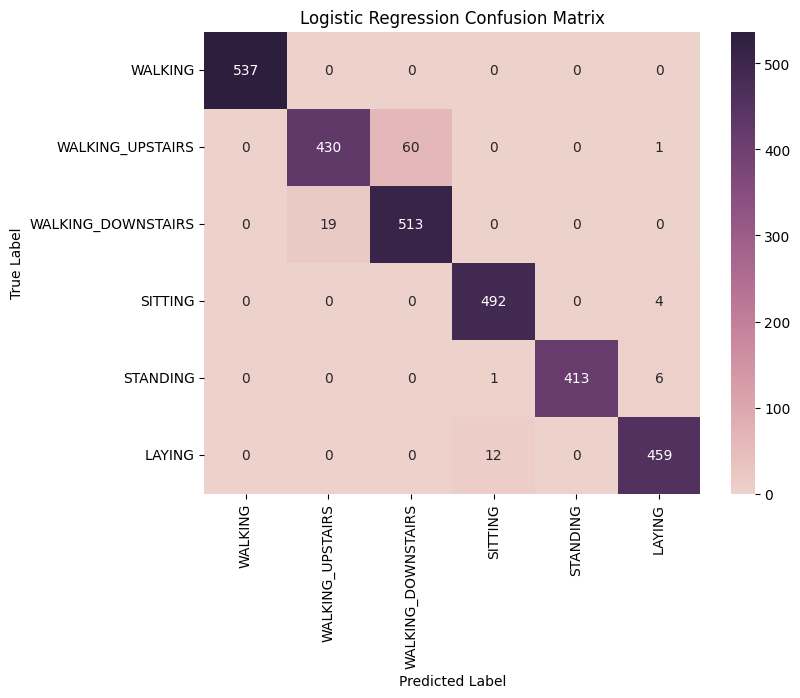

In [ ]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, max_iter=200)
log_reg_model.fit(X_train_lda, train_labels)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_lda)

# Evaluate the model
accuracy_log_reg = log_reg_model.score(X_test_lda, test_labels)
precision_log_reg = precision_score(test_labels, y_pred_log_reg, average='weighted')
recall_log_reg = recall_score(test_labels, y_pred_log_reg, average='weighted')
f1_log_reg = f1_score(test_labels, y_pred_log_reg, average='weighted')

print(f"Logistic Regression Model Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression Model Precision: {precision_log_reg:.4f}")
print(f"Logistic Regression Model Recall: {recall_log_reg:.4f}")
print(f"Logistic Regression Model F1-score: {f1_log_reg:.4f}")

# Plot confusion matrix for Logistic Regression
cm_log_reg = confusion_matrix(test_labels, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=activity_labels_df['activity_name'], yticklabels=activity_labels_df['activity_name'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Random Forest Model Accuracy: 0.9623
Random Forest Model Precision: 0.9635
Random Forest Model Recall: 0.9623
Random Forest Model F1-score: 0.9622


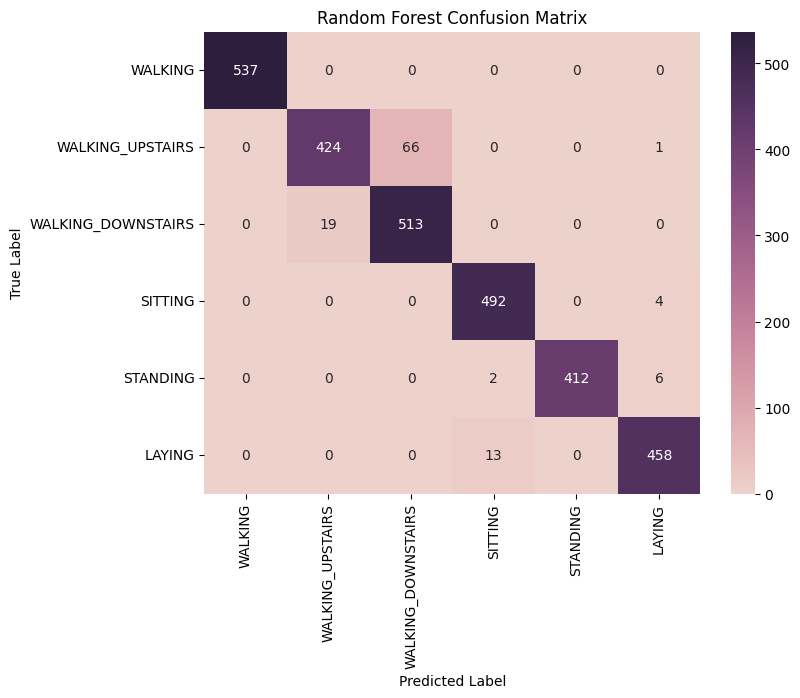

In [ ]:
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators is the number of trees in the forest
rf_model.fit(X_train_lda, train_labels)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_lda)

# Evaluate the model
accuracy_rf = rf_model.score(X_test_lda, test_labels)
precision_rf = precision_score(test_labels, y_pred_rf, average='weighted')
recall_rf = recall_score(test_labels, y_pred_rf, average='weighted')
f1_rf = f1_score(test_labels, y_pred_rf, average='weighted')

print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Model Precision: {precision_rf:.4f}")
print(f"Random Forest Model Recall: {recall_rf:.4f}")
print(f"Random Forest Model F1-score: {f1_rf:.4f}")

# Plot confusion matrix for Random Forest
cm_rf = confusion_matrix(test_labels, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=activity_labels_df['activity_name'], yticklabels=activity_labels_df['activity_name'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

Decision Tree Model Accuracy: 0.9552
Decision Tree Model Precision: 0.9561
Decision Tree Model Recall: 0.9552
Decision Tree Model F1-score: 0.9552


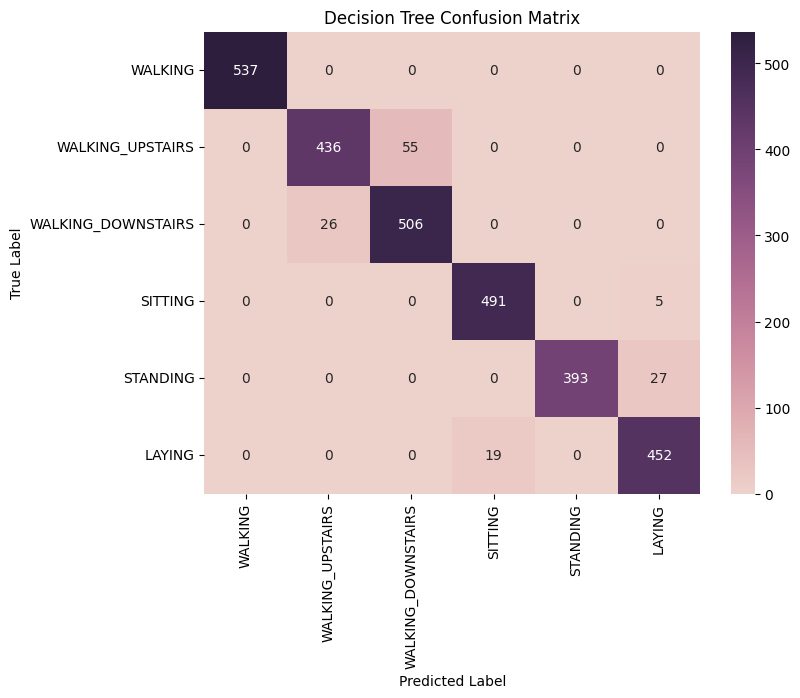

In [ ]:
# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=8) # You can tune hyperparameters like criterion, max_depth etc.
dt_model.fit(X_train_lda, train_labels)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_lda)

# Evaluate the model
accuracy_dt = dt_model.score(X_test_lda, test_labels)
precision_dt = precision_score(test_labels, y_pred_dt, average='weighted')
recall_dt = recall_score(test_labels, y_pred_dt, average='weighted')
f1_dt = f1_score(test_labels, y_pred_dt, average='weighted')

print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Model Precision: {precision_dt:.4f}")
print(f"Decision Tree Model Recall: {recall_dt:.4f}")
print(f"Decision Tree Model F1-score: {f1_dt:.4f}")

# Plot confusion matrix for Decision Tree
cm_dt = confusion_matrix(test_labels, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=activity_labels_df['activity_name'], yticklabels=activity_labels_df['activity_name'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

K-Nearest Neighbors Model Accuracy: 0.9644
K-Nearest Neighbors Model Precision: 0.9655
K-Nearest Neighbors Model Recall: 0.9644
K-Nearest Neighbors Model F1-score: 0.9643


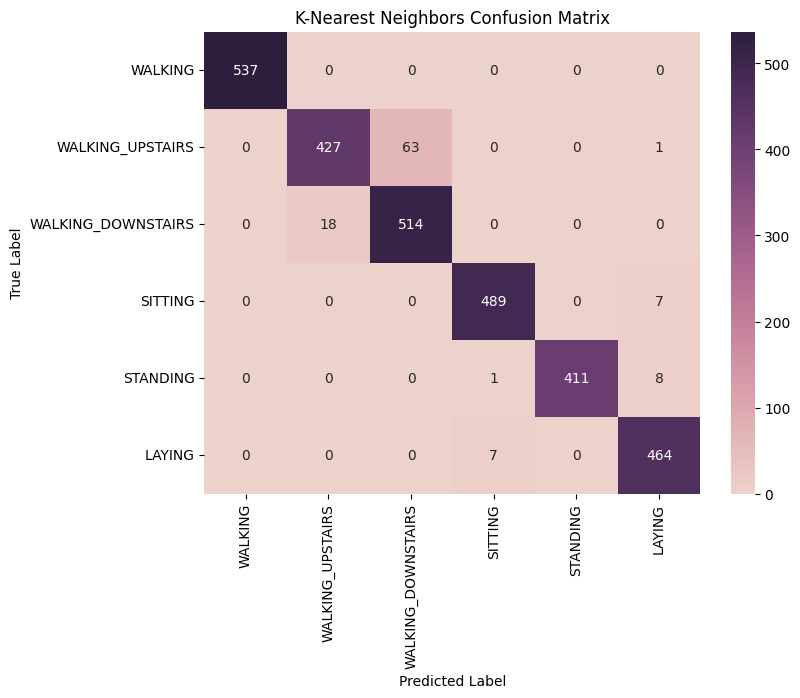

In [ ]:
# Initialize and train the K-Nearest Neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=5) # You can tune the number of neighbors (k)

knn_model.fit(X_train_lda, train_labels)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_lda)

# Evaluate the model
accuracy_knn = knn_model.score(X_test_lda, test_labels)
precision_knn = precision_score(test_labels, y_pred_knn, average='weighted')
recall_knn = recall_score(test_labels, y_pred_knn, average='weighted')
f1_knn = f1_score(test_labels, y_pred_knn, average='weighted')

print(f"K-Nearest Neighbors Model Accuracy: {accuracy_knn:.4f}")
print(f"K-Nearest Neighbors Model Precision: {precision_knn:.4f}")
print(f"K-Nearest Neighbors Model Recall: {recall_knn:.4f}")
print(f"K-Nearest Neighbors Model F1-score: {f1_knn:.4f}")

# Plot confusion matrix for KNN
cm_knn = confusion_matrix(test_labels, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=activity_labels_df['activity_name'], yticklabels=activity_labels_df['activity_name'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.show()

Support Vector Machine Model Accuracy: 0.9630
Support Vector Machine Model Precision: 0.9634
Support Vector Machine Model Recall: 0.9630
Support Vector Machine Model F1-score: 0.9629


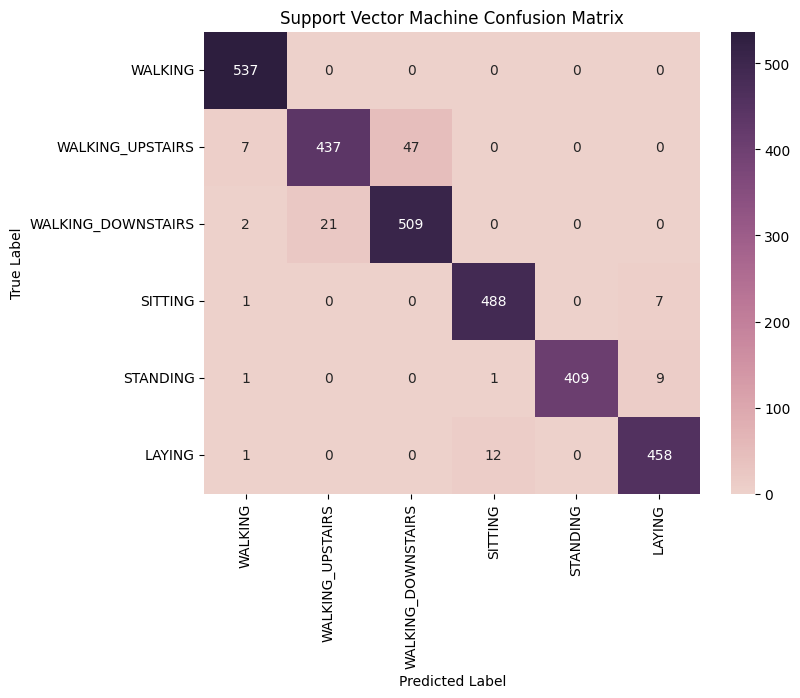

In [ ]:
from sklearn import svm

# Initialize and train the Support Vector Machine (SVM) model
# You can tune hyperparameters like C, kernel, gamma, etc.
svm_model = svm.SVC(kernel='rbf', C=1, gamma='auto', random_state=42)

svm_model.fit(X_train_lda, train_labels)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_lda)

# Evaluate the model
accuracy_svm = svm_model.score(X_test_lda, test_labels)
precision_svm = precision_score(test_labels, y_pred_svm, average='weighted')
recall_svm = recall_score(test_labels, y_pred_svm, average='weighted')
f1_svm = f1_score(test_labels, y_pred_svm, average='weighted')

print(f"Support Vector Machine Model Accuracy: {accuracy_svm:.4f}")
print(f"Support Vector Machine Model Precision: {precision_svm:.4f}")
print(f"Support Vector Machine Model Recall: {recall_svm:.4f}")
print(f"Support Vector Machine Model F1-score: {f1_svm:.4f}")

# Plot confusion matrix for SVM
cm_svm = confusion_matrix(test_labels, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=activity_labels_df['activity_name'], yticklabels=activity_labels_df['activity_name'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Support Vector Machine Confusion Matrix")
plt.show()


In [ ]:
model_accuracies = {
    # 'Neural Network': graph.history['val_accuracy'][-1], # Get the last validation accuracy
    'Logistic Regression': accuracy_log_reg,
    'Random Forest': accuracy_rf,
    'Decision Tree': accuracy_dt,
    'K-Nearest Neighbors': accuracy_knn,
    'Support Vector Machine': accuracy_svm
}

# Find the model with the highest accuracy
highest_accuracy_model_name = max(model_accuracies, key=model_accuracies.get)
highest_accuracy_value = model_accuracies[highest_accuracy_model_name]

print(f"\nSummary of Model Accuracies:")
for model_name, accuracy in model_accuracies.items():
    print(f"{model_name}: {accuracy:.4f}")

print(f"\nThe classification model with the highest accuracy is: {highest_accuracy_model_name} with an accuracy of {highest_accuracy_value *100:.3f}%")


Summary of Model Accuracies:
Logistic Regression: 0.9650
Random Forest: 0.9623
Decision Tree: 0.9552
K-Nearest Neighbors: 0.9644
Support Vector Machine: 0.9630

The classification model with the highest accuracy is: Logistic Regression with an accuracy of 96.505%


Ensemble Model (LR + KNN) Accuracy: 0.9664
Ensemble Model (LR + KNN) Precision: 0.9669
Ensemble Model (LR + KNN) Recall: 0.9664
Ensemble Model (LR + KNN) F1-score: 0.9663


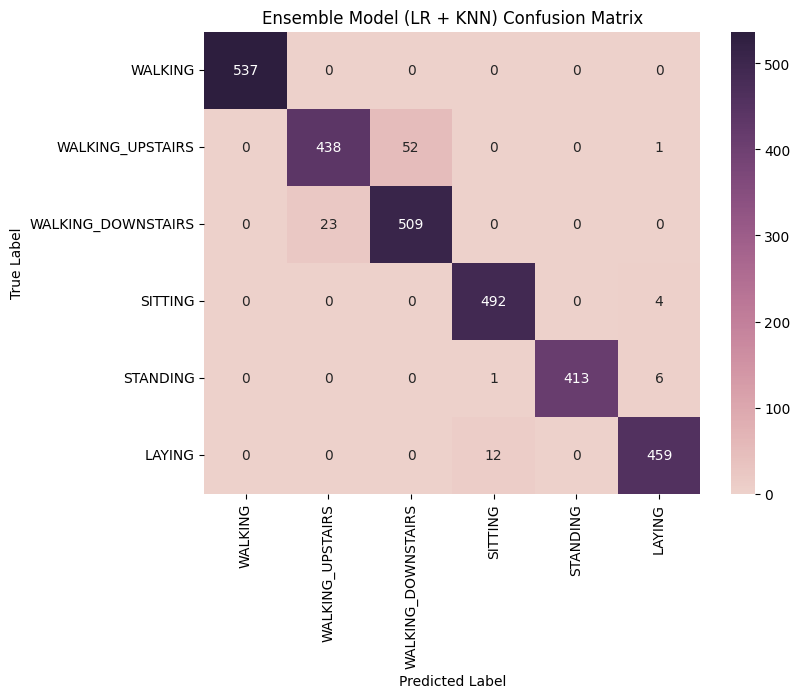

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Create a list of tuples with Logistic Regression and KNN models
estimators_lr_knn = [
    ('lr', log_reg_model),
    ('knn', knn_model)
]

# Create the Voting Classifier with 'hard' voting
ensemble_lr_knn = VotingClassifier(estimators=estimators_lr_knn, voting='hard')

# Train the ensemble model
ensemble_lr_knn.fit(X_train_lda, train_labels)

# Make predictions on the test set
y_pred_ensemble_lr_knn = ensemble_lr_knn.predict(X_test_lda)

# Evaluate the ensemble model
accuracy_ensemble_lr_knn = accuracy_score(test_labels, y_pred_ensemble_lr_knn)
precision_ensemble_lr_knn = precision_score(test_labels, y_pred_ensemble_lr_knn, average='weighted')
recall_ensemble_lr_knn = recall_score(test_labels, y_pred_ensemble_lr_knn, average='weighted')
f1_ensemble_lr_knn = f1_score(test_labels, y_pred_ensemble_lr_knn, average='weighted')

print(f"Ensemble Model (LR + KNN) Accuracy: {accuracy_ensemble_lr_knn:.4f}")
print(f"Ensemble Model (LR + KNN) Precision: {precision_ensemble_lr_knn:.4f}")
print(f"Ensemble Model (LR + KNN) Recall: {recall_ensemble_lr_knn:.4f}")
print(f"Ensemble Model (LR + KNN) F1-score: {f1_ensemble_lr_knn:.4f}")

# Plot confusion matrix for the Ensemble Model (LR + KNN)
cm_ensemble_lr_knn = confusion_matrix(test_labels, y_pred_ensemble_lr_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble_lr_knn, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=activity_labels_df['activity_name'], yticklabels=activity_labels_df['activity_name'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ensemble Model (LR + KNN) Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
model1=LogisticRegression(max_iter=200)
model2=DecisionTreeClassifier(random_state=42, max_depth=8)
model3=KNeighborsClassifier(n_neighbors=5)
ensemble_model = VotingClassifier(
    estimators=[('lr', model1),
                ('dt', model2),
                ('knn', model3)],
     voting='hard')
ensemble_model.fit(X_train_lda,train_labels)
y_pred_ensemble=ensemble_model.predict(X_test_lda)
accuracy_ensemble=accuracy_score(test_labels,y_pred_ensemble)
print(f"Ensemble Model Accuracy: {accuracy_ensemble *100:.3f}%")



Ensemble Model Accuracy: 96.403%


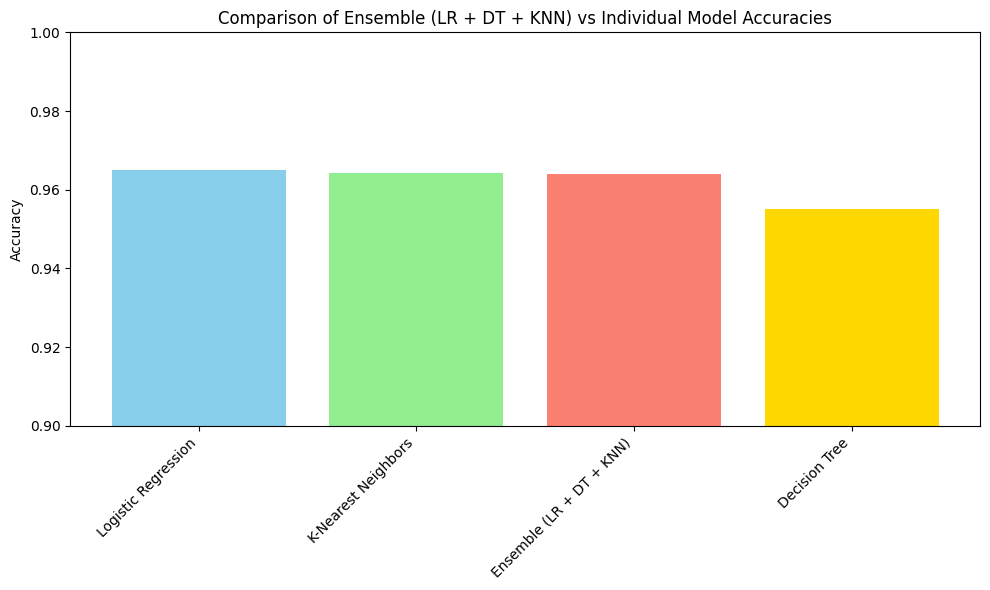

In [ ]:
# Compare with individual model accuracies
individual_accuracies = {
    'Logistic Regression': accuracy_log_reg,
    'Decision Tree': accuracy_dt,
    'K-Nearest Neighbors': accuracy_knn,
    'Ensemble (LR + DT + KNN)': accuracy_ensemble
}

# Sort models by accuracy
sorted_individual_models = sorted(individual_accuracies.items(), key=lambda item: item[1], reverse=True)
individual_model_names = [item[0] for item in sorted_individual_models]
individual_accuracies_values = [item[1] for item in sorted_individual_models]

# Create a bar plot for comparison
plt.figure(figsize=(10, 6))
plt.bar(individual_model_names, individual_accuracies_values, color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.ylabel('Accuracy')
plt.title('Comparison of Ensemble (LR + DT + KNN) vs Individual Model Accuracies')
plt.ylim(0.9, 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


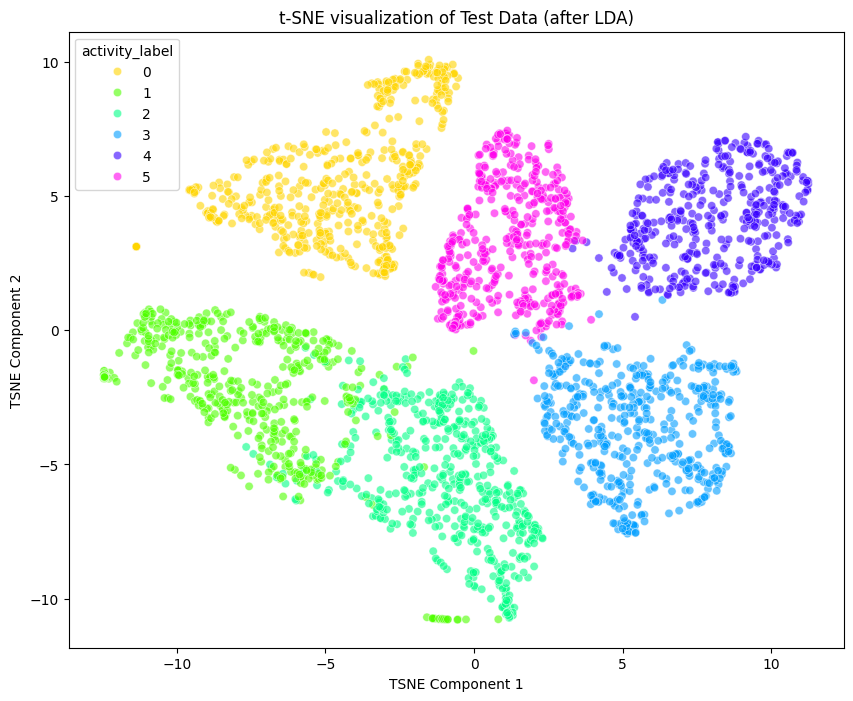

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300) # You can adjust perplexity and n_iter
X_test_tsne = tsne.fit_transform(X_test_lda)

# Create a DataFrame for easier plotting
tsne_df = pd.DataFrame(data=X_test_tsne, columns=['TSNE_Component_1', 'TSNE_Component_2'])
tsne_df['activity_label'] = test_labels.values # Add the true labels for coloring

# Plot the t-SNE results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_Component_1', y='TSNE_Component_2',
    hue='activity_label',
    palette=sns.color_palette("hsv", len(activity_labels_df)), # Use a distinct color palette
    data=tsne_df,
    legend="full",
    alpha=0.6
)
plt.title('t-SNE visualization of Test Data (after LDA)')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.show()

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

base_classifier=DecisionTreeClassifier()
bagging_model=BaggingClassifier(estimator=base_classifier,n_estimators=100,random_state=42)
bagging_model.fit(X_train_lda,train_labels)

y_pred_bagging=bagging_model.predict(X_test_lda)
accuracy_bagging=accuracy_score(test_labels,y_pred_bagging)
print(f"Bagging Model Accuracy:", accuracy_bagging)

Bagging Model Accuracy: 0.9589412962334578


# Task
Explain how to increase the accuracy of a bagging model.

## Hyperparameter tuning

### Subtask:
Tune the `n_estimators` and `max_samples` parameters of the `BaggingClassifier`.


**Reasoning**:
I need to tune the hyperparameters of the BaggingClassifier using GridSearchCV to find the best combination of n_estimators and max_samples that maximizes accuracy.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0]
}

# Initialize the BaggingClassifier
bagging_base = DecisionTreeClassifier(random_state=42)
bagging_model = BaggingClassifier(estimator=bagging_base, random_state=42)

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=bagging_model, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search.fit(X_train_lda, train_labels)

# Print the best parameters
print("Best parameters found by GridSearchCV:", grid_search.best_params_)

# Evaluate the bagging model with the best parameters on the test set
best_bagging_model = grid_search.best_estimator_
y_pred_bagging_tuned = best_bagging_model.predict(X_test_lda)
accuracy_bagging_tuned = accuracy_score(test_labels, y_pred_bagging_tuned)

print(f"Tuned Bagging Model Accuracy: {accuracy_bagging_tuned:.4f}")

Best parameters found by GridSearchCV: {'max_samples': 0.5, 'n_estimators': 100}
Tuned Bagging Model Accuracy: 0.9613


## Feature selection

### Subtask:
Explore feature selection techniques to see if a subset of features can improve performance.


**Reasoning**:
Import necessary modules for feature selection and apply SelectKBest to the training and test data to select the top k features. Then, train a Bagging Classifier on the selected features and evaluate its performance.



In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize SelectKBest with f_classif as the score function and k=10
kbest = SelectKBest(score_func=f_classif, k=10)

# Fit SelectKBest to the training data and transform
X_train_selected = kbest.fit_transform(train_features, train_labels)

# Transform the test features
X_test_selected = kbest.transform(test_features)

# Initialize and train the BaggingClassifier with potentially tuned hyperparameters
# Using the best parameters found in the previous step: n_estimators=100, max_samples=0.5
base_classifier = DecisionTreeClassifier(random_state=42)
bagging_model_selected = BaggingClassifier(estimator=base_classifier, n_estimators=100, max_samples=0.5, random_state=42)
bagging_model_selected.fit(X_train_selected, train_labels)

# Make predictions on the selected test features
y_pred_bagging_selected = bagging_model_selected.predict(X_test_selected)

# Evaluate the model
accuracy_bagging_selected = accuracy_score(test_labels, y_pred_bagging_selected)

print(f"Bagging Model Accuracy with selected features: {accuracy_bagging_selected:.4f}")
print(f"Previous Bagging Model Accuracy (tuned): {accuracy_bagging_tuned:.4f}")


Bagging Model Accuracy with selected features: 0.7469
Previous Bagging Model Accuracy (tuned): 0.9613


## Cross-validation

### Subtask:
Implement cross-validation to get a more robust evaluation of the model's performance.


**Reasoning**:
Import cross_val_score and evaluate the BaggingClassifier with the best base estimator and hyperparameters using cross-validation.



In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Choose the best performing base estimator (Logistic Regression or K-Nearest Neighbors)
# Based on the previous step, both Logistic Regression and K-Nearest Neighbors had the highest accuracy.
# Let's choose Logistic Regression for this example.
best_base_estimator = LogisticRegression(max_iter=200, random_state=42)

# Initialize BaggingClassifier with the best base estimator and tuned hyperparameters
# Best hyperparameters from tuning step: n_estimators=100, max_samples=0.5
bagging_model_cv = BaggingClassifier(estimator=best_base_estimator, n_estimators=100, max_samples=0.5, random_state=42)

# Perform 5-fold cross-validation on the training data
cv_scores = cross_val_score(bagging_model_cv, X_train_lda, train_labels, cv=5, scoring='accuracy')

# Print the mean accuracy and standard deviation of the cross-validation scores
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores):.4f}")

Cross-validation accuracy scores: [0.97824609 0.98980286 0.97142857 0.9952381  0.98979592]
Mean cross-validation accuracy: 0.9849
Standard deviation of cross-validation accuracy: 0.0087
